# Fraud Detection ML Pipeline (CRISP-DM)

**Objective:** Predict `orders.is_fraud` from `shop.db` using an end-to-end, reproducible ML pipeline.

This notebook follows the **CRISP-DM** process:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Feature Selection
7. Finalization (artifacts + scoring)

---

## 1) Business Understanding

### Problem statement
Fraudulent orders create direct financial loss (chargebacks, refunds, inventory loss) and operational cost (manual reviews). The goal is to build a model that assigns a **fraud risk score** to each order so the business can:
- automatically block very high-risk orders, and/or
- route medium-risk orders to manual review.

### Success criteria
Because fraud is typically **rare**, accuracy is not the right primary metric.
- **Primary metric:** PR-AUC (Average Precision) and/or **Recall at a chosen review rate**.
- **Secondary metrics:** precision, recall, F1, ROC-AUC, calibration.

### Operating decision / threshold
We will choose a threshold based on an operational constraint (example):
- Review the top **1–5%** of orders by predicted fraud probability.

### Costs (conceptual)
False negatives (missed fraud) usually cost more than false positives (extra review), so the threshold should generally favor recall.


In [1]:
import os
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
    TimeSeriesSplit,
    cross_validate,
)
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

DB_PATH = Path("./shop.db")
assert DB_PATH.exists(), (
    f"Database file not found at {DB_PATH.resolve()}\n"
    "Place shop.db in the same folder as this notebook, then re-run." 
)

conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA foreign_keys = ON;")


## 2) Data Understanding

We will:
- Inspect the SQLite database structure.
- Load `orders` (and optionally related tables).
- Explore distributions, missingness, and relationships to `is_fraud`.


In [2]:
def sql_df(query: str, params=None) -> pd.DataFrame:
    return pd.read_sql_query(query, conn, params=params)


def list_tables() -> pd.DataFrame:
    return sql_df("SELECT name, type FROM sqlite_master WHERE type IN ('table','view') ORDER BY type, name;")


def table_info(table_name: str) -> pd.DataFrame:
    return sql_df(f"PRAGMA table_info({table_name});")


def row_count(table_name: str) -> int:
    return int(sql_df(f"SELECT COUNT(*) AS n FROM {table_name};").loc[0, "n"])


tables = list_tables()
tables

,name,type
0,customers,table
1,order_items,table
2,orders,table
3,product_reviews,table
4,products,table
5,shipments,table
6,sqlite_sequence,table


In [3]:
assert (tables["name"] == "orders").any(), "Expected an `orders` table in shop.db"

print("orders rows:", row_count("orders"))
display(table_info("orders"))

# target distribution
fraud_counts = sql_df("SELECT is_fraud, COUNT(*) AS n FROM orders GROUP BY is_fraud ORDER BY is_fraud;")
display(fraud_counts)

# Convert target distribution into a normalized rate (best-effort for common encodings)
raw_labels = fraud_counts["is_fraud"].astype(str)
print("Raw label values:", list(raw_labels))

orders rows: 5000


,cid,name,type,notnull,dflt_value,pk
0,0,order_id,INTEGER,0,None,1
1,1,customer_id,INTEGER,1,None,0
2,2,order_datetime,TEXT,1,None,0
3,3,billing_zip,TEXT,0,None,0
4,4,shipping_zip,TEXT,0,None,0
5,5,shipping_state,TEXT,0,None,0
6,6,payment_method,TEXT,1,None,0
7,7,device_type,TEXT,1,None,0
8,8,ip_country,TEXT,1,None,0
9,9,promo_used,INTEGER,1,0,0


,is_fraud,n
0,0,4682
1,1,318


Raw label values: ['0', '1']


In [4]:
def pick_first(existing: set[str], candidates: list[str]) -> str | None:
    for c in candidates:
        if c in existing:
            return c
    return None


def load_orders_dataframe() -> pd.DataFrame:
    """Load a modeling dataframe.

    Baseline: `orders` only.
    If related tables exist, attempt to enrich via simple joins using common key names.
    """
    table_names = set(tables["name"].tolist())

    # Start with orders
    df = sql_df("SELECT * FROM orders;")

    # Best-effort enrichment: add customer attributes if table exists
    if "customers" in table_names:
        orders_cols = set(df.columns)
        cust = sql_df("SELECT * FROM customers;")
        cust_cols = set(cust.columns)

        orders_customer_key = pick_first(orders_cols, ["customer_id", "cust_id", "user_id"])
        cust_key = pick_first(cust_cols, ["customer_id", "cust_id", "id", "user_id"])

        if orders_customer_key and cust_key:
            cust = cust.add_prefix("customer__")
            df = df.merge(
                cust,
                left_on=orders_customer_key,
                right_on=f"customer__{cust_key}",
                how="left",
            )

    # Best-effort enrichment: add payment attributes if table exists
    if "payments" in table_names:
        orders_cols = set(df.columns)
        pay = sql_df("SELECT * FROM payments;")
        pay_cols = set(pay.columns)

        orders_payment_key = pick_first(orders_cols, ["payment_id", "transaction_id"])
        pay_key = pick_first(pay_cols, ["payment_id", "transaction_id", "id"])

        if orders_payment_key and pay_key:
            pay = pay.add_prefix("payment__")
            df = df.merge(
                pay,
                left_on=orders_payment_key,
                right_on=f"payment__{pay_key}",
                how="left",
            )

    return df


df_raw = load_orders_dataframe()
df_raw.shape, df_raw.columns[:20]

((5000, 29),
 Index(['order_id', 'customer_id', 'order_datetime', 'billing_zip',
        'shipping_zip', 'shipping_state', 'payment_method', 'device_type',
        'ip_country', 'promo_used', 'promo_code', 'order_subtotal',
        'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'is_fraud',
        'customer__customer_id', 'customer__full_name', 'customer__email'],
       dtype='object'))

In [5]:
df_raw.head()

,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,...,customer__email,customer__gender,customer__birthdate,customer__created_at,customer__city,customer__state,customer__zip_code,customer__customer_segment,customer__loyalty_tier,customer__is_active
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,...,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,...,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,...,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1
3,4,1,2025-11-06 18:21:19,28289,28289,CO,bank,mobile,US,1,...,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1
4,5,1,2025-11-30 05:34:15,28289,28289,CO,card,mobile,CA,0,...,patriciadiallo0@example.com,Female,2005-06-08,2025-10-11 16:37:40,Clayton,CO,28289,standard,silver,1


In [6]:
# Basic feature-level exploration (Ch. 6)

missing = (
    df_raw.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)

display(missing.head(25))

numeric_cols = df_raw.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in df_raw.columns if c not in numeric_cols]

print("# numeric:", len(numeric_cols))
print("# categorical/other:", len(cat_cols))

if numeric_cols:
    display(df_raw[numeric_cols].describe().T.head(25))

# Top categories for a few categorical columns
for c in cat_cols[:8]:
    vc = df_raw[c].astype(str).value_counts(dropna=False).head(10)
    display(vc.rename_axis(c).to_frame("count"))

,missing_rate
promo_code,0.7478
order_id,0.0000
risk_score,0.0000
customer__loyalty_tier,0.0000
customer__customer_segment,0.0000
customer__zip_code,0.0000
customer__state,0.0000
customer__city,0.0000
customer__created_at,0.0000
customer__birthdate,0.0000


# numeric: 11
# categorical/other: 18


,count,mean,std,min,25%,50%,75%,max
order_id,5000.0,2500.500000,1443.520003,1.00,1250.75,2500.500,3750.2500,5000.00
customer_id,5000.0,28.448200,49.086939,1.00,2.00,6.000,28.0000,250.00
promo_used,5000.0,0.252200,0.434319,0.00,0.00,0.000,1.0000,1.00
order_subtotal,5000.0,384.144678,284.124017,4.73,164.18,330.720,549.7525,1921.17
shipping_fee,5000.0,9.668290,5.126125,0.00,6.99,8.040,12.9900,28.14
tax_amount,5000.0,27.738312,21.446470,0.25,11.47,23.365,39.1525,148.13
order_total,5000.0,421.551280,305.183694,5.38,185.76,364.835,596.9400,2053.11
risk_score,5000.0,26.115940,27.433842,0.10,4.60,14.500,40.2250,100.00
is_fraud,5000.0,0.063600,0.244063,0.00,0.00,0.000,0.0000,1.00
customer__customer_id,5000.0,28.448200,49.086939,1.00,2.00,6.000,28.0000,250.00


,count
order_datetime,
2025-11-29 00:51:07,1
2025-10-16 12:30:02,1
2025-12-23 23:13:41,1
2025-11-09 22:49:41,1
2025-10-15 15:25:04,1
2025-10-13 13:02:59,1
2025-10-10 09:13:51,1
2025-08-23 03:09:14,1
2025-09-13 04:28:27,1


,count
billing_zip,
28289,1156
88907,471
46421,316
70217,250
16006,184
56566,155
45382,139
44718,106
62581,103


...

,count
shipping_state,
CO,1702
OH,390
MI,367
TX,350
NC,338
AZ,296
FL,244
IL,232
WA,164


,count
payment_method,
card,3128
paypal,1050
bank,725
crypto,97


,count
device_type,
mobile,2734
desktop,1902
tablet,364


,count
ip_country,
US,4496
CA,218
GB,104
IN,95
NG,46
BR,41


,count
promo_code,
None,3739
SAVE10,258
VIP20,257
FREESHIP,255
STUDENT,246
WELCOME,245


Dropped rows with missing target: 0
Fraud rate: 0.0636


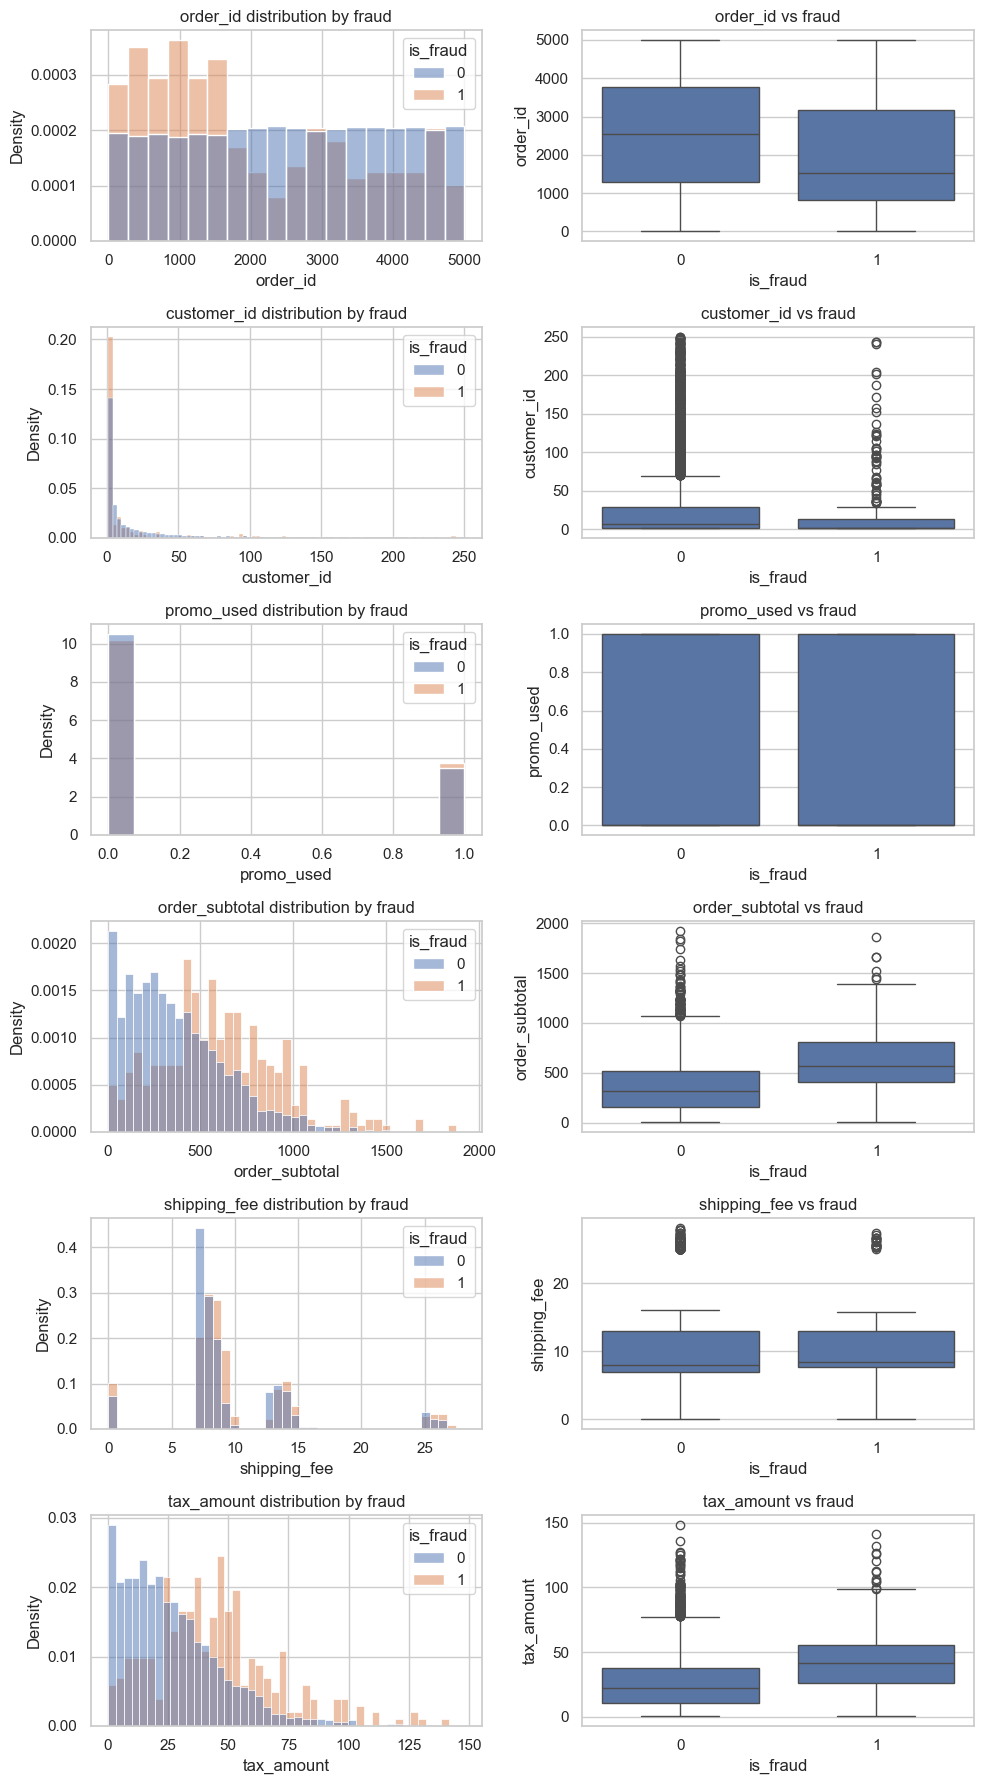

,order_datetime,mean,count
0,2025-07-09 17:11:18,0.0,1
1,2025-11-05 20:11:38,0.0,1
2,2025-11-06 05:26:59,0.0,1
3,2025-11-06 04:32:42,0.0,1
4,2025-11-06 02:57:27,0.0,1
5,2025-11-06 02:47:47,0.0,1
6,2025-11-06 00:30:49,0.0,1
7,2025-11-06 00:25:38,0.0,1
8,2025-11-05 23:44:34,0.0,1
9,2025-11-05 20:01:16,0.0,1


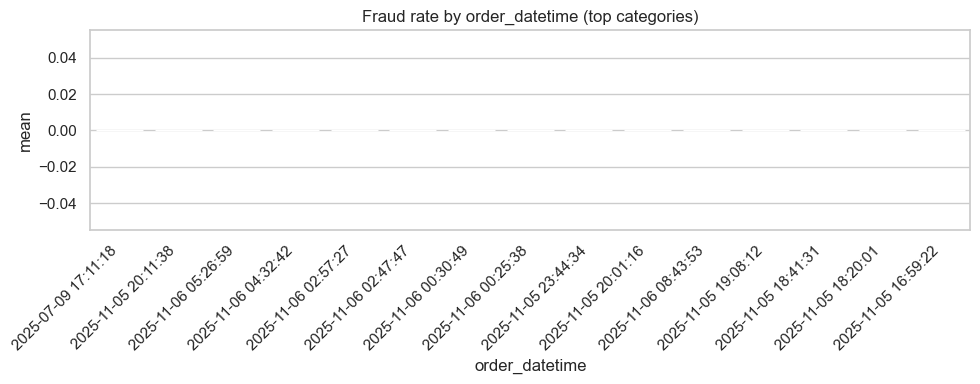

,billing_zip,mean,count
0,28289,0.101211,1156
1,88907,0.110403,471
2,46421,0.047468,316
3,70217,0.044,250
4,16006,0.016304,184
5,56566,0.032258,155
6,45382,0.035971,139
7,44718,0.066038,106
8,62581,0.058252,103
9,76784,0.084337,83


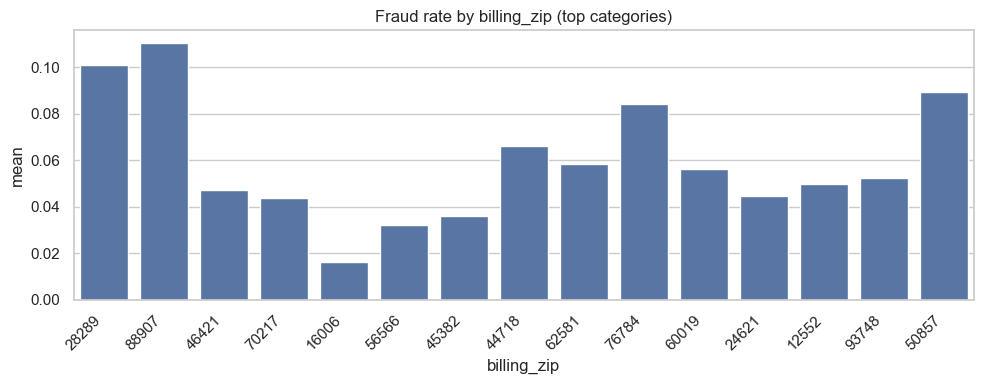

,shipping_zip,mean,count
0,28289,0.092628,1058
1,88907,0.099078,434
2,46421,0.050847,295
3,70217,0.043478,230
4,16006,0.017341,173
5,56566,0.028571,140
6,45382,0.039683,126
7,44718,0.068627,102
8,62581,0.060606,99
9,76784,0.04,75


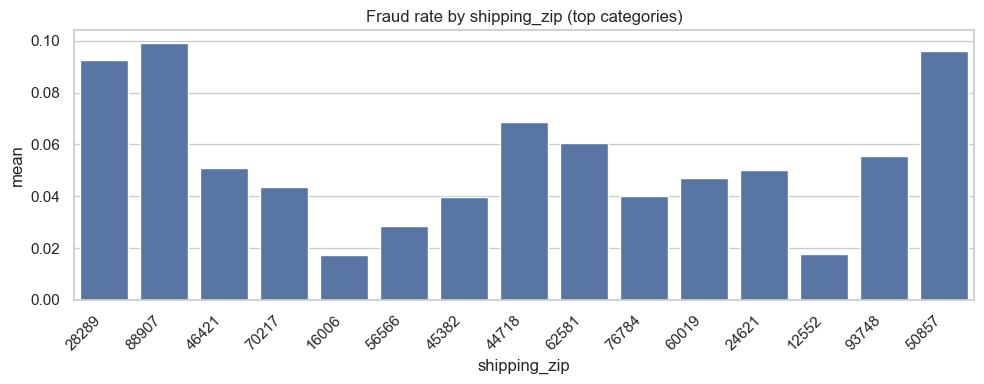

,shipping_state,mean,count
0,CO,0.091657,1702
1,OH,0.048718,390
2,MI,0.040872,367
3,TX,0.082857,350
4,NC,0.04142,338
5,AZ,0.030405,296
6,FL,0.057377,244
7,IL,0.038793,232
8,WA,0.060976,164
9,NY,0.040268,149


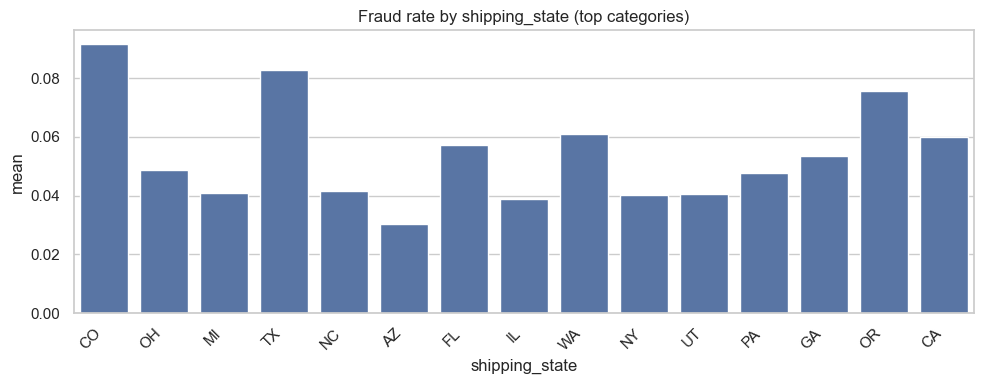

,payment_method,mean,count
0,card,0.067455,3128
1,paypal,0.051429,1050
2,bank,0.05931,725
3,crypto,0.103093,97


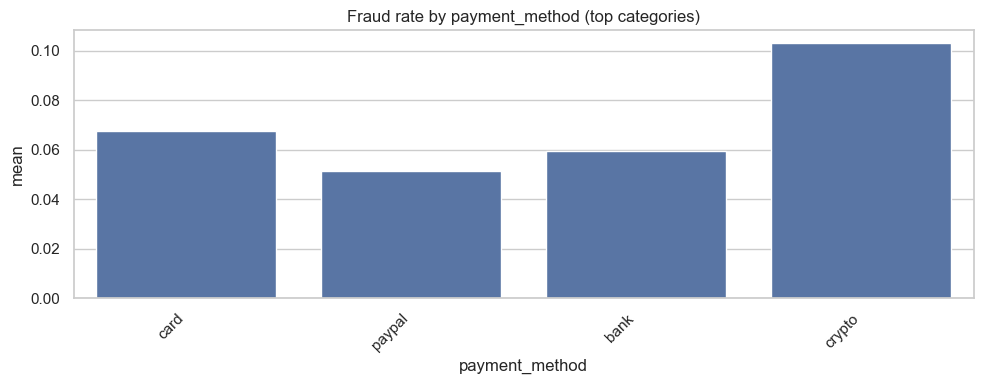

,device_type,mean,count
0,mobile,0.068032,2734
1,desktop,0.056782,1902
2,tablet,0.065934,364


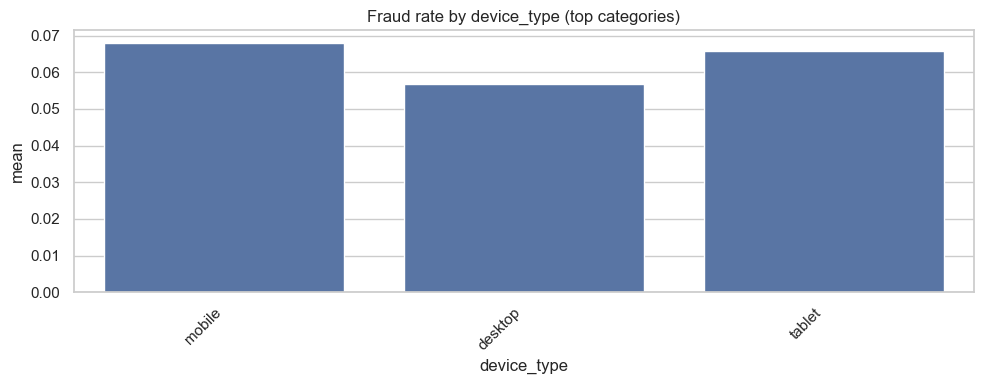

In [7]:
# Relationship discovery (Ch. 8): compare features vs fraud

TARGET_COL = "is_fraud"
assert TARGET_COL in df_raw.columns, "orders table must include is_fraud"

# Coerce target into 0/1
true_tokens = {"1", "true", "t", "yes", "y"}
false_tokens = {"0", "false", "f", "no", "n"}

def coerce_binary(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()
    out = pd.Series(np.nan, index=s.index, dtype="float")
    out[s.isin(true_tokens)] = 1.0
    out[s.isin(false_tokens)] = 0.0
    # If already numeric-like but not matched, try to parse
    mask = out.isna()
    if mask.any():
        parsed = pd.to_numeric(s[mask], errors="coerce")
        out.loc[mask] = parsed
    return out.astype("Int64")


df = df_raw.copy()
df[TARGET_COL] = coerce_binary(df[TARGET_COL])

# Drop rows where target is missing/unparseable
before = len(df)
df = df[df[TARGET_COL].notna()].copy()
print("Dropped rows with missing target:", before - len(df))

fraud_rate = df[TARGET_COL].mean()
print(f"Fraud rate: {fraud_rate:.4f}")

# Quick plots for up to a few numeric features
plot_num = [c for c in numeric_cols if c != TARGET_COL][:6]
if plot_num:
    fig, axes = plt.subplots(nrows=len(plot_num), ncols=2, figsize=(10, 3 * len(plot_num)))
    if len(plot_num) == 1:
        axes = np.array([axes])

    for i, c in enumerate(plot_num):
        sns.histplot(data=df, x=c, hue=TARGET_COL, stat="density", common_norm=False, ax=axes[i, 0])
        axes[i, 0].set_title(f"{c} distribution by fraud")
        sns.boxplot(data=df, x=TARGET_COL, y=c, ax=axes[i, 1])
        axes[i, 1].set_title(f"{c} vs fraud")
    plt.tight_layout()
    plt.show()

# Fraud rate by category for a few categorical columns
plot_cat = [c for c in cat_cols if c != TARGET_COL][:6]
for c in plot_cat:
    tmp = (
        df.groupby(c, dropna=False)[TARGET_COL]
        .agg(["mean", "count"])
        .sort_values(["count"], ascending=False)
        .head(15)
        .reset_index()
    )
    display(tmp)
    plt.figure(figsize=(10, 4))
    sns.barplot(data=tmp, x=c, y="mean")
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Fraud rate by {c} (top categories)")
    plt.tight_layout()
    plt.show()

## 3) Data Preparation

We will:
- Clean types (timestamps, booleans).
- Engineer a few robust features when the relevant columns exist.
- Build a reusable preprocessing pipeline (Ch. 7) using `ColumnTransformer`.
- Split train/test with leakage awareness (time split if available).


In [8]:
def parse_datetime_columns(df_in: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    df_out = df_in.copy()
    dt_cols: list[str] = []

    # Heuristic: any column containing these tokens could be datetime
    candidates = [c for c in df_out.columns if any(t in c.lower() for t in ["date", "time", "created", "timestamp"])]

    for c in candidates:
        if pd.api.types.is_datetime64_any_dtype(df_out[c]):
            dt_cols.append(c)
            continue

        # Try parsing if it looks like strings/ints
        parsed = pd.to_datetime(df_out[c], errors="coerce", utc=True)
        # Accept if enough values parse
        if parsed.notna().mean() >= 0.6 and parsed.nunique(dropna=True) >= 10:
            df_out[c] = parsed
            dt_cols.append(c)

    return df_out, dt_cols


def add_datetime_features(df_in: pd.DataFrame, dt_cols: list[str]) -> pd.DataFrame:
    df_out = df_in.copy()
    for c in dt_cols:
        # Use UTC components for consistency
        s = df_out[c]
        if not pd.api.types.is_datetime64_any_dtype(s):
            continue
        base = c.lower()
        df_out[f"{base}__hour"] = s.dt.hour
        df_out[f"{base}__dayofweek"] = s.dt.dayofweek
        df_out[f"{base}__month"] = s.dt.month
    return df_out


def engineer_features(df_in: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    df1, dt_cols = parse_datetime_columns(df_in)
    df2 = add_datetime_features(df1, dt_cols)

    # Robust numeric transforms (only when columns exist)
    for amt_col in ["amount", "total", "total_amount", "order_total", "payment_amount"]:
        if amt_col in df2.columns and pd.api.types.is_numeric_dtype(df2[amt_col]):
            df2[f"{amt_col}__log1p"] = np.log1p(df2[amt_col].clip(lower=0))

    return df2, dt_cols


# Apply feature engineering

df_fe, detected_dt_cols = engineer_features(df)
print("Detected datetime columns:", detected_dt_cols)
print("Shape after feature engineering:", df_fe.shape)

Detected datetime columns: ['order_datetime', 'customer__birthdate', 'customer__created_at']
Shape after feature engineering: (5000, 39)


In [9]:
# Split strategy: time-based if a usable datetime exists, else stratified random split

def choose_time_column(df_in: pd.DataFrame, dt_cols: list[str]) -> str | None:
    # Prefer something like created_at/order_date if present
    preferred = [
        "created_at",
        "order_date",
        "order_datetime",
        "timestamp",
        "date",
    ]
    cols = set(df_in.columns)
    for p in preferred:
        if p in cols and pd.api.types.is_datetime64_any_dtype(df_in[p]):
            return p

    # Otherwise choose the datetime with most non-null values
    best = None
    best_rate = 0.0
    for c in dt_cols:
        rate = df_in[c].notna().mean()
        if rate > best_rate:
            best = c
            best_rate = rate
    return best


time_col = choose_time_column(df_fe, detected_dt_cols)
print("Chosen time column:", time_col)

X = df_fe.drop(columns=[TARGET_COL])
y = df_fe[TARGET_COL].astype(int)

if time_col is not None:
    # Hold out the most recent 20% by time
    order = X[time_col].sort_values().index
    cutoff = int(len(order) * 0.8)
    train_idx = order[:cutoff]
    test_idx = order[cutoff:]
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]
    split_kind = f"time_split({time_col})"
else:
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    train_idx, test_idx = next(sss.split(X, y))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    split_kind = "stratified_split"

print("Split:", split_kind)
print("Train size:", len(X_train), "Test size:", len(X_test))
print("Train fraud rate:", y_train.mean(), "Test fraud rate:", y_test.mean())

Chosen time column: order_datetime
Split: time_split(order_datetime)
Train size: 4000 Test size: 1000
Train fraud rate: 0.067 Test fraud rate: 0.05


In [10]:
# Build preprocessing pipeline (Ch. 7)

# Separate by dtype (after feature engineering)
num_features = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_features = [c for c in X_train.columns if c not in num_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
)

# IMPORTANT: HistGradientBoostingClassifier requires dense X.
# OneHotEncoder defaults to sparse output, so we force dense output for compatibility.
import inspect

def make_ohe_dense() -> OneHotEncoder:
    sig = inspect.signature(OneHotEncoder)
    if "sparse_output" in sig.parameters:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    # older scikit-learn
    return OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe_dense()),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder="drop",
)

print("Numeric features:", len(num_features))
print("Categorical features:", len(cat_features))

Numeric features: 20
Categorical features: 18


## 4) Modeling

We will train multiple classification models (baseline + ensembles) using the same preprocessing pipeline.


dummy_most_frequent
{'model': 'dummy_most_frequent', 'test_fraud_rate': 0.05, 'roc_auc': 0.5, 'pr_auc': 0.05}
Confusion matrix:
 [[950   0]
 [ 50   0]]
              precision    recall  f1-score   support

           0     0.9500    1.0000    0.9744       950
           1     0.0000    0.0000    0.0000        50

    accuracy                         0.9500      1000
   macro avg     0.4750    0.5000    0.4872      1000
weighted avg     0.9025    0.9500    0.9256      1000



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

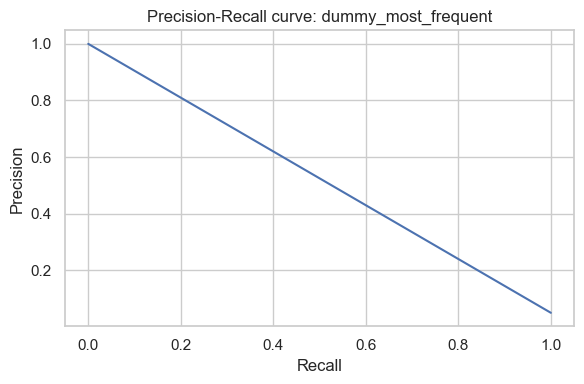

logreg_balanced
{'model': 'logreg_balanced', 'test_fraud_rate': 0.05, 'roc_auc': 0.7572842105263159, 'pr_auc': 0.14361688131187308}
Confusion matrix:
 [[871  79]
 [ 37  13]]
              precision    recall  f1-score   support

           0     0.9593    0.9168    0.9376       950
           1     0.1413    0.2600    0.1831        50

    accuracy                         0.8840      1000
   macro avg     0.5503    0.5884    0.5603      1000
weighted avg     0.9184    0.8840    0.8998      1000



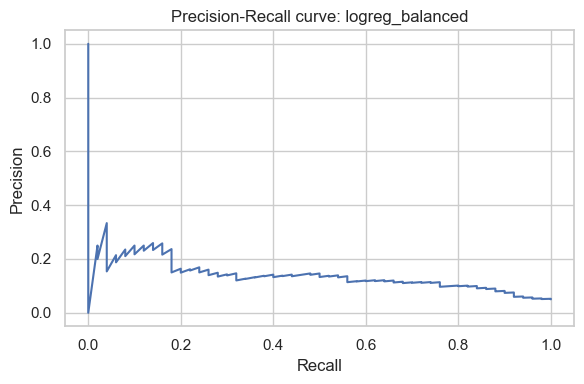

rf
{'model': 'rf', 'test_fraud_rate': 0.05, 'roc_auc': 0.7610736842105263, 'pr_auc': 0.1394501583656163}
Confusion matrix:
 [[950   0]
 [ 50   0]]
              precision    recall  f1-score   support

           0     0.9500    1.0000    0.9744       950
           1     0.0000    0.0000    0.0000        50

    accuracy                         0.9500      1000
   macro avg     0.4750    0.5000    0.4872      1000
weighted avg     0.9025    0.9500    0.9256      1000



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

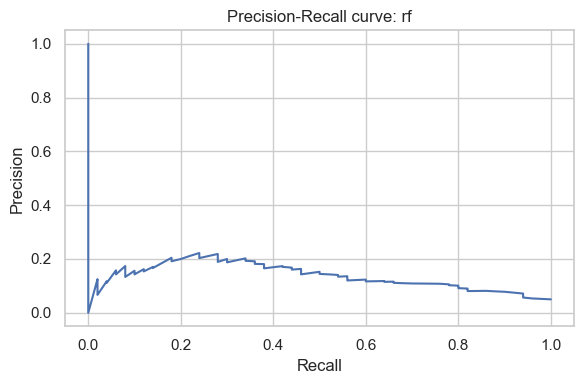

hgb
{'model': 'hgb', 'test_fraud_rate': 0.05, 'roc_auc': 0.7711789473684211, 'pr_auc': 0.13430674278251867}
Confusion matrix:
 [[946   4]
 [ 50   0]]
              precision    recall  f1-score   support

           0     0.9498    0.9958    0.9723       950
           1     0.0000    0.0000    0.0000        50

    accuracy                         0.9460      1000
   macro avg     0.4749    0.4979    0.4861      1000
weighted avg     0.9023    0.9460    0.9236      1000



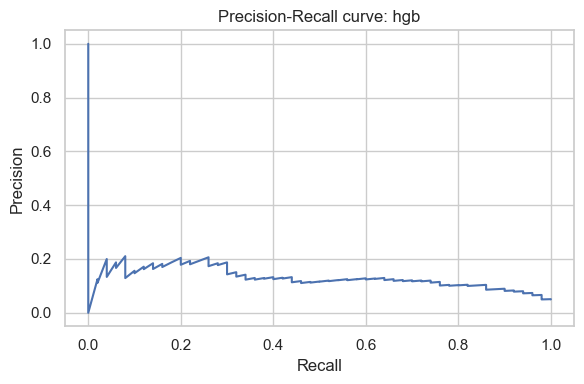

,model,test_fraud_rate,roc_auc,pr_auc
1,logreg_balanced,0.05,0.757284,0.143617
2,rf,0.05,0.761074,0.139450
3,hgb,0.05,0.771179,0.134307
0,dummy_most_frequent,0.05,0.500000,0.050000


In [11]:
models: dict[str, object] = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "logreg_balanced": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=None,
    ),
    "rf": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1,
    ),
    "hgb": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        max_depth=None,
    ),
}


def evaluate_model(name: str, clf) -> dict:
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", clf)])
    pipe.fit(X_train, y_train)

    proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None
    pred = pipe.predict(X_test)

    out = {
        "model": name,
        "test_fraud_rate": float(y_test.mean()),
        "roc_auc": float(roc_auc_score(y_test, proba)) if proba is not None else np.nan,
        "pr_auc": float(average_precision_score(y_test, proba)) if proba is not None else np.nan,
    }

    print("=" * 80)
    print(name)
    print(out)
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, digits=4))

    if proba is not None:
        precision, recall, thresholds = precision_recall_curve(y_test, proba)
        plt.figure(figsize=(6, 4))
        plt.plot(recall, precision)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall curve: {name}")
        plt.tight_layout()
        plt.show()

    return out, pipe


results = []
fitted_pipes: dict[str, Pipeline] = {}
for name, clf in models.items():
    res, pipe = evaluate_model(name, clf)
    results.append(res)
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
results_df

## 5) Evaluation, model selection, and tuning

We will:
- Select a leading model based on PR-AUC.
- Tune hyperparameters.
- Choose an operating threshold based on an operational review-rate constraint.


Selected for tuning: logreg_balanced
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

Best CV PR-AUC: 0.19263564358264387
Best params:
  model__solver = lbfgs
  model__penalty = l2
  model__C = 0.001
Test ROC-AUC: 0.808336842105263
Test PR-AUC: 0.18634379502884676


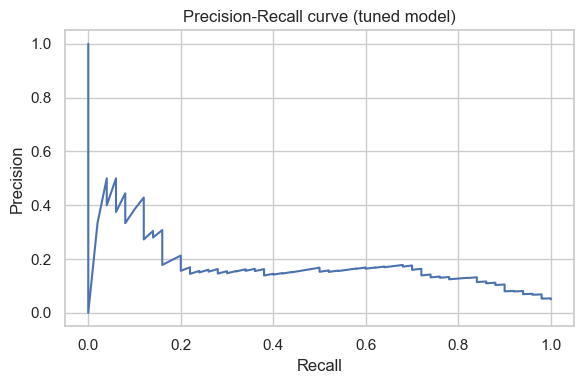

In [12]:
from sklearn.model_selection import RandomizedSearchCV

# Choose best from quick comparison
best_name = results_df.iloc[0]["model"]
base_pipe = fitted_pipes[best_name]
print("Selected for tuning:", best_name)

# Define search spaces for a couple of likely winners
param_distributions = None
if best_name == "rf":
    param_distributions = {
        "model__n_estimators": [300, 500, 800],
        "model__max_depth": [None, 6, 10, 16],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
    }
elif best_name == "logreg_balanced":
    param_distributions = {
        "model__C": np.logspace(-3, 2, 20),
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
    }
elif best_name == "hgb":
    param_distributions = {
        "model__learning_rate": [0.01, 0.03, 0.06, 0.1],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__max_depth": [None, 3, 6, 10],
        "model__min_samples_leaf": [20, 50, 100],
        "model__l2_regularization": [0.0, 0.1, 1.0],
    }
else:
    # Fallback: tune a strong default (HGB)
    best_name = "hgb"
    base_pipe = Pipeline(steps=[("preprocess", preprocess), ("model", models["hgb"])])
    param_distributions = {
        "model__learning_rate": [0.01, 0.03, 0.06, 0.1],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__min_samples_leaf": [20, 50, 100],
    }

# CV strategy
if time_col is not None:
    cv = TimeSeriesSplit(n_splits=5)
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=base_pipe,
    param_distributions=param_distributions,
    n_iter=min(20, sum(len(v) if hasattr(v, "__len__") else 10 for v in param_distributions.values())),
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)
print("Best CV PR-AUC:", search.best_score_)
print("Best params:")
for k, v in search.best_params_.items():
    print(" ", k, "=", v)

best_pipe = search.best_estimator_

# Evaluate tuned model on test
proba_test = best_pipe.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(y_test, proba_test))
print("Test PR-AUC:", average_precision_score(y_test, proba_test))

precision, recall, thresholds = precision_recall_curve(y_test, proba_test)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve (tuned model)")
plt.tight_layout()
plt.show()

In [13]:
# Threshold selection using an operational review-rate constraint

REVIEW_RATE = 0.03  # review top 3% highest-risk orders

n_review = max(1, int(len(proba_test) * REVIEW_RATE))
thresh = np.sort(proba_test)[-n_review]

pred_flag = (proba_test >= thresh).astype(int)

print("Review rate:", REVIEW_RATE)
print("Chosen threshold:", float(thresh))
print("Flagged for review:", int(pred_flag.sum()), "/", len(pred_flag))
print("Confusion matrix (at review threshold):\n", confusion_matrix(y_test, pred_flag))
print(classification_report(y_test, pred_flag, digits=4))

# Also show precision/recall at that point
prec = (pred_flag[y_test == 1].sum() / max(1, pred_flag.sum())) if pred_flag.sum() else 0.0
rec = pred_flag[y_test == 1].sum() / max(1, int((y_test == 1).sum()))
print(f"Precision@{REVIEW_RATE:.0%}: {prec:.4f}")
print(f"Recall@{REVIEW_RATE:.0%}: {rec:.4f}")

Review rate: 0.03
Chosen threshold: 0.7809542212095592
Flagged for review: 30 / 1000
Confusion matrix (at review threshold):
 [[928  22]
 [ 42   8]]
              precision    recall  f1-score   support

           0     0.9567    0.9768    0.9667       950
           1     0.2667    0.1600    0.2000        50

    accuracy                         0.9360      1000
   macro avg     0.6117    0.5684    0.5833      1000
weighted avg     0.9222    0.9360    0.9283      1000

Precision@3%: 0.2667
Recall@3%: 0.1600


## 6) Feature selection (Ch. 16)

We’ll use **permutation importance** (model-agnostic) on the tuned pipeline to identify the most influential features, then optionally fit a reduced feature set to compare performance.


,feature,importance_mean,importance_std
15,risk_score,0.030352,0.013588
11,order_subtotal,0.010355,0.005653
14,order_total,0.010014,0.005817
30,order_datetime__month,0.004319,0.007311
23,customer__state,0.003269,0.001646
13,tax_amount,0.002985,0.005568
0,order_id,0.002862,0.002235
21,customer__created_at,0.002263,0.001372
32,customer__birthdate__dayofweek,0.001760,0.001822
17,customer__full_name,0.001665,0.001139


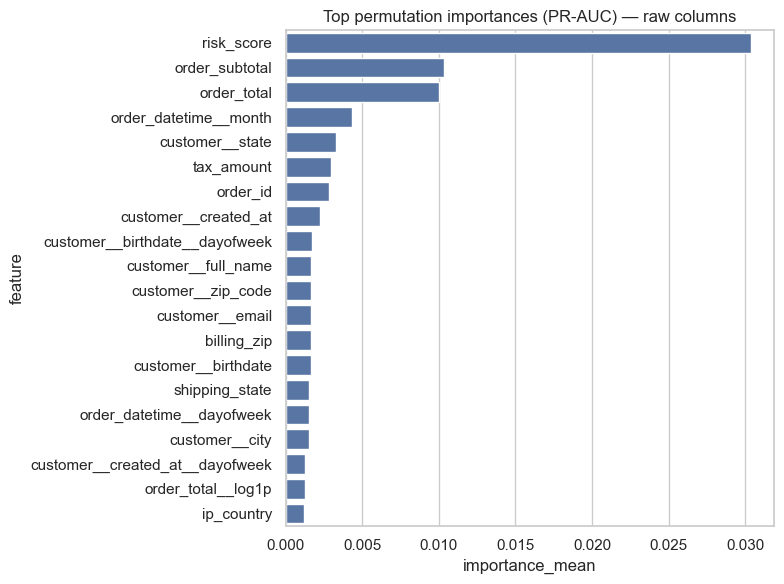

In [14]:
from sklearn.inspection import permutation_importance

# Compute permutation importance on a subsample for speed
X_test_sample = X_test.copy()
y_test_sample = y_test.copy()

if len(X_test_sample) > 5000:
    X_test_sample = X_test_sample.sample(5000, random_state=RANDOM_STATE)
    y_test_sample = y_test.loc[X_test_sample.index]

# IMPORTANT: When you pass a full Pipeline into permutation_importance,
# it permutes the *raw input columns* (X_test_sample), not the one-hot-expanded columns.
perm = permutation_importance(
    best_pipe,
    X_test_sample,
    y_test_sample,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="average_precision",
)

feature_names = X_test_sample.columns.tolist()

imp = pd.DataFrame(
    {
        "feature": feature_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

display(imp.head(30))

plt.figure(figsize=(8, 6))
sns.barplot(data=imp.head(20), x="importance_mean", y="feature")
plt.title("Top permutation importances (PR-AUC) — raw columns")
plt.tight_layout()
plt.show()

In [15]:
# Optional: refit using only top-K raw input columns

TOPK_RAW_COLS = 15

selected_raw = imp.head(TOPK_RAW_COLS)["feature"].tolist()
selected_raw = [c for c in selected_raw if c in X_train.columns]
print("Selected raw columns:", selected_raw)

X_train_fs = X_train[selected_raw].copy()
X_test_fs = X_test[selected_raw].copy()

# Rebuild preprocess with selected columns
num_fs = X_train_fs.select_dtypes(include=["number"]).columns.tolist()
cat_fs = [c for c in X_train_fs.columns if c not in num_fs]

preprocess_fs = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_fs),
        ("cat", categorical_transformer, cat_fs),
    ],
    remainder="drop",
)

# Keep same best model class with best params when possible
# IMPORTANT: clone the model so we don't mutate `best_pipe` by refitting the same estimator instance.
from sklearn.base import clone

best_model = clone(search.best_estimator_.named_steps["model"])
pipe_fs = Pipeline(steps=[("preprocess", preprocess_fs), ("model", best_model)])
pipe_fs.fit(X_train_fs, y_train)

proba_fs = pipe_fs.predict_proba(X_test_fs)[:, 1]
print("FS Test PR-AUC:", average_precision_score(y_test, proba_fs))
print("FS Test ROC-AUC:", roc_auc_score(y_test, proba_fs))

Selected raw columns: ['risk_score', 'order_subtotal', 'order_total', 'order_datetime__month', 'customer__state', 'tax_amount', 'order_id', 'customer__created_at', 'customer__birthdate__dayofweek', 'customer__full_name', 'customer__zip_code', 'customer__email', 'billing_zip', 'customer__birthdate', 'shipping_state']
FS Test PR-AUC: 0.19190079164431212
FS Test ROC-AUC: 0.8109052631578948


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 7) Finalize: scoring function (single-notebook workflow)

In class, it’s common to keep everything in **one notebook**.

Here we:
- keep the tuned pipeline (`best_pipe`) and threshold (`thresh`) **in memory**
- define a `score_orders()` helper that outputs a fraud probability and `fraud_flag`

(If you ever need to persist the model later, you can add saving back in—but it’s not required for CRISP-DM.)


In [16]:
# Keep run metadata in-memory (no extra files created)

run_metadata = {
    "db_path": str(DB_PATH),
    "split_kind": split_kind,
    "time_col": time_col,
    "review_rate": REVIEW_RATE,
    "threshold": float(thresh),
    "test_pr_auc": float(average_precision_score(y_test, proba_test)),
    "test_roc_auc": float(roc_auc_score(y_test, proba_test)),
}

run_metadata

{'db_path': 'shop.db',
 'split_kind': 'time_split(order_datetime)',
 'time_col': 'order_datetime',
 'review_rate': 0.03,
 'threshold': 0.7809542212095592,
 'test_pr_auc': 0.18634379502884676,
 'test_roc_auc': 0.808336842105263}

In [17]:
def score_orders(df_orders: pd.DataFrame, pipeline: Pipeline, threshold: float) -> pd.DataFrame:
    proba = pipeline.predict_proba(df_orders)[:, 1]
    out = df_orders.copy()
    out["fraud_proba"] = proba
    out["fraud_flag"] = (out["fraud_proba"] >= threshold).astype(int)
    return out.sort_values("fraud_proba", ascending=False)


# Example: score the test set
scored = score_orders(X_test, best_pipe, float(thresh))
display(scored[["fraud_proba", "fraud_flag"]].head(10))

,fraud_proba,fraud_flag
210,0.911294,1
442,0.906597,1
2940,0.891429,1
294,0.889329,1
257,0.881011,1
347,0.870331,1
964,0.869794,1
1425,0.864079,1
939,0.847618,1
1452,0.847529,1


## Limitations and next steps

- **Label quality**: `is_fraud` may be delayed/incorrect (chargebacks discovered later). Consider label windows.
- **Leakage risk**: if any post-order outcomes are included (e.g., chargeback status), remove them.
- **Concept drift**: fraud patterns change; monitor PR-AUC/recall-at-review-rate over time and retrain.
- **Fairness & compliance**: review features for unintended bias (e.g., geography as a proxy).


### Export for deployment (Supabase / nightly scoring)

After you have `best_pipe` and `thresh` from training, run this once to write the artifacts expected by `jobs/run_fraud_inference.py`:

```python
from pathlib import Path
import joblib

ART = Path("artifacts/fraud_artifacts.joblib")
ART.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"pipeline": best_pipe, "threshold": float(thresh)}, ART)
print("Saved", ART.resolve())
```

Commit `artifacts/fraud_artifacts.joblib` (or store it in CI secrets / release assets) so GitHub Actions can load it.

In [ ]:
from pathlib import Path
import joblib

ART = Path("artifacts/fraud_artifacts.joblib")
ART.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"pipeline": best_pipe, "threshold": float(thresh)}, ART)
print("Saved", ART.resolve())